In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [3]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['Extracurricular Activities']=encoder.fit_transform(df['Extracurricular Activities'])
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


In [4]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]
X

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5
...,...,...,...,...,...
9995,1,49,1,4,2
9996,7,64,1,8,5
9997,6,83,1,8,5
9998,9,97,1,7,0


In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [7]:
X_test

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
6252,5,69,0,8,2
4684,2,46,1,4,8
1731,7,56,1,7,5
4742,6,42,1,8,5
4521,7,53,0,4,6
...,...,...,...,...,...
4862,6,94,0,6,4
7025,2,56,0,6,2
7647,5,81,0,8,8
7161,4,72,0,5,3


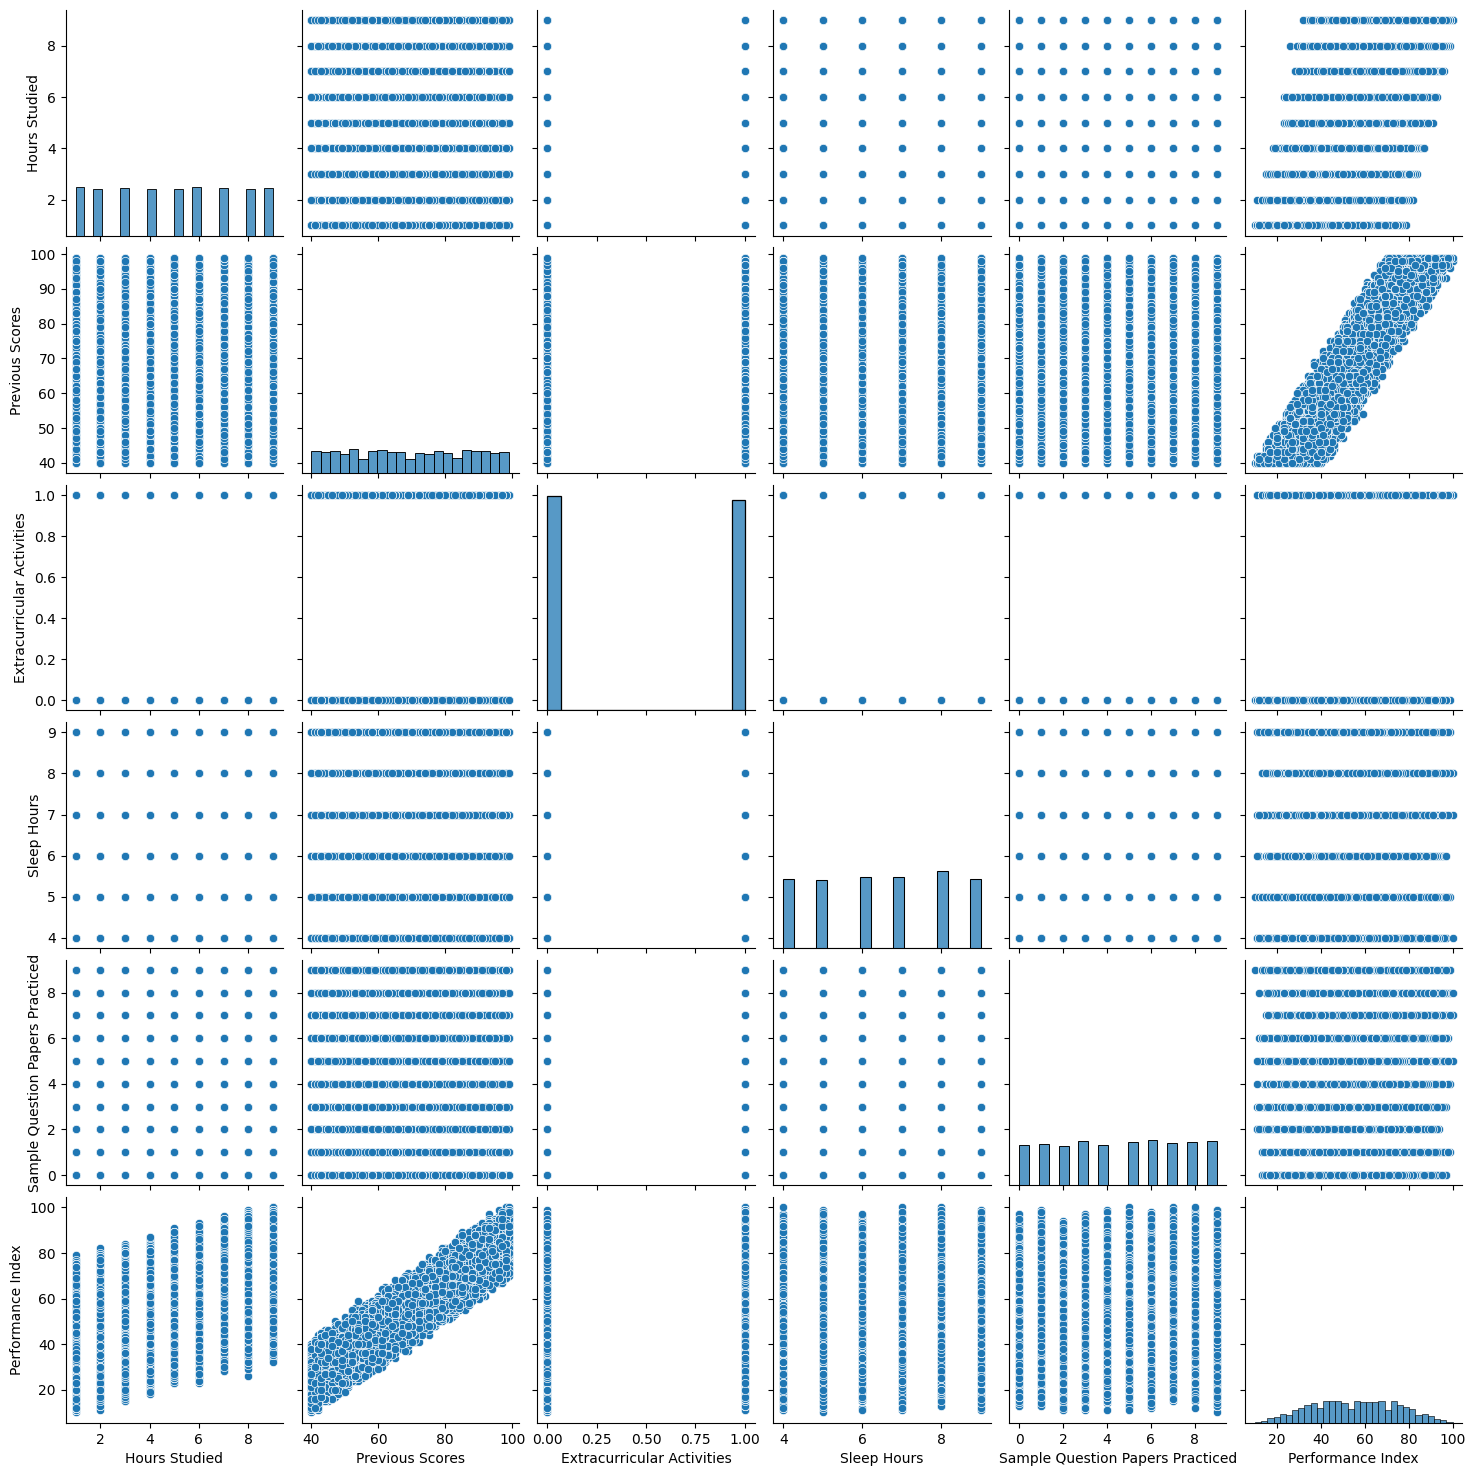

In [17]:
sns.pairplot(df)

In [59]:
X_train[:,:1]

array([[ 0.00796272],
       [ 0.77854894],
       [-0.76262349],
       ...,
       [ 1.54913515],
       [-1.5332097 ],
       [-1.14791659]])

In [79]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
X_train=scalar.fit_transform(X_train)
X_test=scalar.transform(X_test)

In [80]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression1=LinearRegression()
regression.fit(X_train,y_train)
regression1.fit(X_train[:,:1],y_train)

LinearRegression()

In [81]:
y_pred=regression.predict(X_test)
y_pred

array([55.43024038, 23.21710852, 48.66416509, ..., 68.75538458,
       54.34123218, 55.63083271])

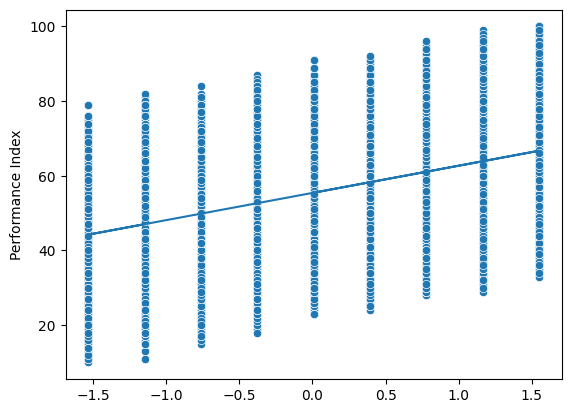

In [82]:
sns.scatterplot(x=X_train[:,:1].flatten(),y=y_train)
plt.plot(X_train[:,:1],regression1.predict(X_train[:,:1]))

In [34]:
residual=(y_pred-y_test)
residual

6252    4.430240
4684    3.217109
1731    2.664165
4742    4.042017
4521    2.780583
          ...   
4862    0.123165
7025    1.614966
7647   -1.244615
7161   -1.658768
73      3.630833
Name: Performance Index, Length: 2500, dtype: float64

In [72]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

4.636837605606022
1.7239573815343698
2.15333174536717
